## Example: 2D simulation of Taylor Green Vortex using Lattice Boltzmann Method


The example solves the Naiver Stokes Equation using Lattice Boltzmann Method. Here we setup the problem using an analytical solution of N-S equation: Taylor Green Vortex. Its velocity field and pressure field can be written as


$$u= -u_{\max} \cos \frac{2\pi x}{L} \sin \frac{2\pi y}{L} e^{-\nu t} $$ 

$$ v=u_{\max}\sin \frac{2\pi x}{L} \cos \frac{2\pi y}{L} e^{-\nu t} $$

$$p= -\frac {1}{4}  \rho_0 u_{\max}^2 ( \cos \frac{2\pi x}{L} + \cos \frac{2\pi y}{L} ) e^{-2\nu t} $$

Here, the Boltzmann equation is written as

$$\frac{\partial f}{\partial t}+ \xi_\alpha \frac{\partial f}{\partial x_\alpha} +\frac{f_\alpha}{\rho}\frac{\partial f}{\partial \xi_\alpha}=\Omega(f),$$

where the probability density function $f(\mathbf{x},\mathbf{\xi}, t)$, which is defined as a function of location $\mathbf{x}$, microscopic particle velocity $\mathbf{\xi}$, and time $t$. $f_\alpha$ is external forcing, and $\Omega(f)$ is the collision term.

The problem is solved in 2D using D2Q9 discretization, and the collision term is solved using BGK operator.


## Running the code

The simulation can be ran as `./mained.gnu.ex inputs`. 

The following inputs parameters could be tweaked:

```
scale = 2              # scale of the problem
max_grid_size = 64                # max grid size used for domain decomposition
Nx = 32    # size of the domain in both directions are Nx*scale
NSTEP=200  # number of time steps is NSTEP*scale*scale
plot_int=50 # interval of saving data, if not save, then set as -1
```


## Visualizating the results

Below we give some python code to visualizate the solution using yt:

In [1]:
import yt
from yt.frontends import boxlib
from yt.frontends.boxlib.data_structures import AMReXDataset

/tmp/ipykernel_3246928/3074286631.py:3: DeprecationWarning: The historic 'boxlib' frontend is 
deprecated as it has been renamed 'amrex'. Existing and future work should instead reference the 'amrex' frontend.
Deprecated since yt 4.4.0
  from yt.frontends.boxlib.data_structures import AMReXDataset


yt : [INFO     ] 2024-12-16 23:09:42,600 Parameters: current_time              = 0.0
yt : [INFO     ] 2024-12-16 23:09:42,601 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2024-12-16 23:09:42,602 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2024-12-16 23:09:42,603 Parameters: domain_right_edge         = [64. 64.  1.]
yt : [INFO     ] 2024-12-16 23:09:42,836 xlim = 0.000000 64.000000
yt : [INFO     ] 2024-12-16 23:09:42,837 ylim = 0.000000 64.000000
yt : [INFO     ] 2024-12-16 23:09:42,840 xlim = 0.000000 64.000000
yt : [INFO     ] 2024-12-16 23:09:42,841 ylim = 0.000000 64.000000
yt : [INFO     ] 2024-12-16 23:09:42,849 Making a fixed resolution buffer of (('boxlib', 'ux')) 800 by 800
yt : [INFO     ] 2024-12-16 23:09:43,548 min value is -1.99518e-02 at 0.5000000000000000 15.5000000000000000 0.5000000000000000



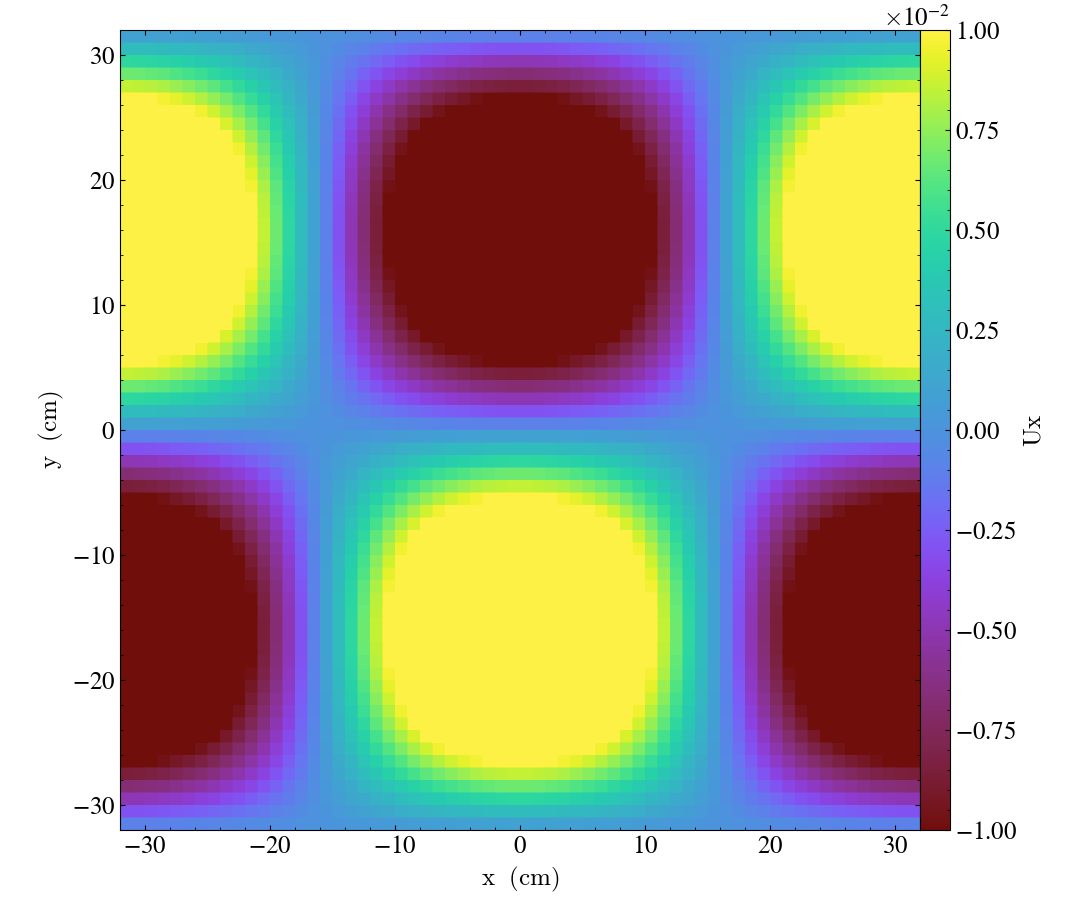

In [2]:
ds = AMReXDataset("plt00000")
sl = yt.SlicePlot(ds, 2, ('boxlib', 'ux'))
sl.set_log(('ux'), False)
sl.set_zlim(('ux'), -0.01, 0.01)
# 
ds.find_min("ux")
sl

yt : [INFO     ] 2024-12-16 23:09:44,134 Parameters: current_time              = 300.0
yt : [INFO     ] 2024-12-16 23:09:44,135 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2024-12-16 23:09:44,136 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2024-12-16 23:09:44,137 Parameters: domain_right_edge         = [64. 64.  1.]
yt : [INFO     ] 2024-12-16 23:09:44,262 xlim = 0.000000 64.000000
yt : [INFO     ] 2024-12-16 23:09:44,263 ylim = 0.000000 64.000000
yt : [INFO     ] 2024-12-16 23:09:44,266 xlim = 0.000000 64.000000
yt : [INFO     ] 2024-12-16 23:09:44,267 ylim = 0.000000 64.000000
yt : [INFO     ] 2024-12-16 23:09:44,270 Making a fixed resolution buffer of (('boxlib', 'ux')) 800 by 800



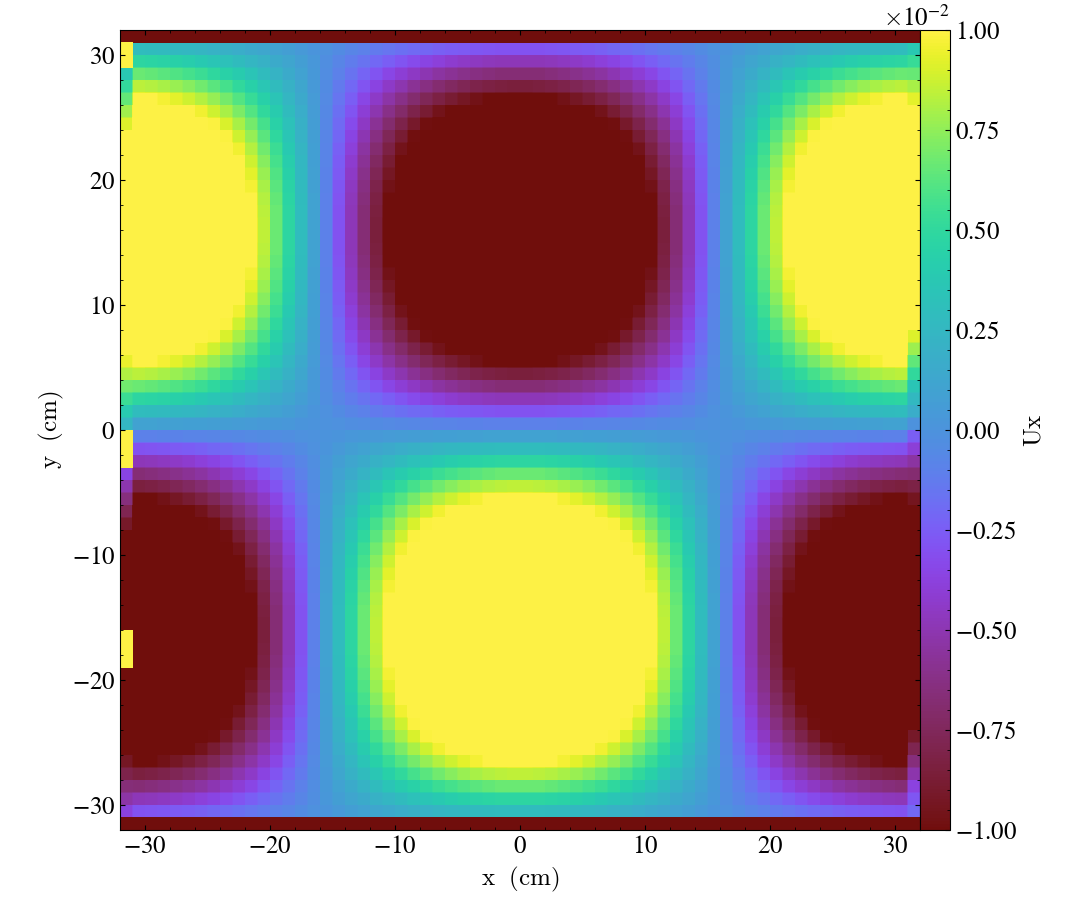

In [3]:

ds = AMReXDataset("plt00300")
sl = yt.SlicePlot(ds, 2, ('boxlib', 'ux'))
sl.set_log(('ux'), False)
sl.set_zlim(('ux'), -0.01, 0.01)
# ds.find_min("ux")
sl

## Validation of the results using analytical solution

yt : [INFO     ] 2024-12-16 23:09:45,157 Parameters: current_time              = 0.0
yt : [INFO     ] 2024-12-16 23:09:45,158 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2024-12-16 23:09:45,159 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2024-12-16 23:09:45,160 Parameters: domain_right_edge         = [64. 64.  1.]
yt : [INFO     ] 2024-12-16 23:09:45,411 Parameters: current_time              = 50.0
yt : [INFO     ] 2024-12-16 23:09:45,412 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2024-12-16 23:09:45,413 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2024-12-16 23:09:45,414 Parameters: domain_right_edge         = [64. 64.  1.]


Time: 0, Error in ux: 1.3946642886348142, Error in uy: 1.4122028276647616, Error in rho: 1.4142135623730967
Time: 50, Error in ux: 5.274136986387977, Error in uy: 4.502293436006929, Error in rho: 220.73915108949325


yt : [INFO     ] 2024-12-16 23:09:45,584 Parameters: current_time              = 100.0
yt : [INFO     ] 2024-12-16 23:09:45,585 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2024-12-16 23:09:45,586 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2024-12-16 23:09:45,587 Parameters: domain_right_edge         = [64. 64.  1.]
yt : [INFO     ] 2024-12-16 23:09:45,759 Parameters: current_time              = 150.0
yt : [INFO     ] 2024-12-16 23:09:45,760 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2024-12-16 23:09:45,761 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2024-12-16 23:09:45,762 Parameters: domain_right_edge         = [64. 64.  1.]


Time: 100, Error in ux: 6.163374642269808, Error in uy: 5.250831288032429, Error in rho: 304.38112540589316
Time: 150, Error in ux: 7.212015400372298, Error in uy: 6.134962413310887, Error in rho: 419.7143092645479


yt : [INFO     ] 2024-12-16 23:09:45,933 Parameters: current_time              = 200.0
yt : [INFO     ] 2024-12-16 23:09:45,934 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2024-12-16 23:09:45,936 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2024-12-16 23:09:45,936 Parameters: domain_right_edge         = [64. 64.  1.]
yt : [INFO     ] 2024-12-16 23:09:46,108 Parameters: current_time              = 250.0
yt : [INFO     ] 2024-12-16 23:09:46,109 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2024-12-16 23:09:46,109 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2024-12-16 23:09:46,110 Parameters: domain_right_edge         = [64. 64.  1.]


...

Time: 600, Error in ux: 30.35147498289018, Error in uy: 25.71264908960081, Error in rho: 7563.633684627411
Time: 650, Error in ux: 35.636046741175825, Error in uy: 30.18698048796066, Error in rho: 10429.399647581671


yt : [INFO     ] 2024-12-16 23:09:47,819 Parameters: current_time              = 700.0
yt : [INFO     ] 2024-12-16 23:09:47,820 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2024-12-16 23:09:47,821 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2024-12-16 23:09:47,822 Parameters: domain_right_edge         = [64. 64.  1.]
yt : [INFO     ] 2024-12-16 23:09:48,003 Parameters: current_time              = 750.0
yt : [INFO     ] 2024-12-16 23:09:48,004 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2024-12-16 23:09:48,005 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2024-12-16 23:09:48,006 Parameters: domain_right_edge         = [64. 64.  1.]


Time: 700, Error in ux: 41.842296001080726, Error in uy: 35.44193873380736, Error in rho: 14380.96524509106
Time: 750, Error in ux: 49.13071738358129, Error in uy: 41.6134181244108, Error in rho: 19829.725140708775


yt : [INFO     ] 2024-12-16 23:09:48,181 Parameters: current_time              = 800.0
yt : [INFO     ] 2024-12-16 23:09:48,182 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2024-12-16 23:09:48,183 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2024-12-16 23:09:48,184 Parameters: domain_right_edge         = [64. 64.  1.]


Time: 800, Error in ux: 57.6897905521698, Error in uy: 48.86101417558868, Error in rho: 27342.945823931652


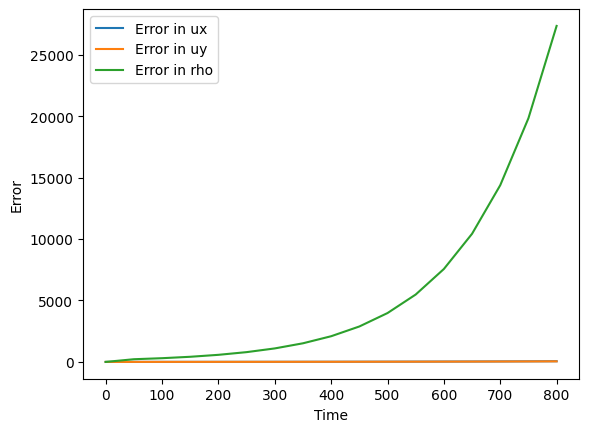

In [4]:
import numpy as np
import matplotlib.pyplot as plt
L=64
u_max=0.02
rho0=1
kx=2*np.pi/L
ky=2*np.pi/L
nu=1/6
td= td = 1.0 / (nu * (kx * kx + ky * ky))

xxx=np.linspace(0,L-1,L)+.5
yyy=np.linspace(0,L-1,L)+.5
xmesh,ymesh = np.meshgrid(xxx,yyy,indexing='ij')
xmesh = xmesh.flatten()
ymesh = ymesh.flatten()
time_list=[]
error_ux_list=[]
error_uy_list=[]
error_rho_list=[]
for time in range(0,850,50):
    ux_analytic = -u_max*np.sqrt(ky/kx)*np.cos(kx*xmesh)*np.sin(ky*ymesh)*np.exp(-1.0*time/td)
    uy_analytic = u_max*np.sqrt(kx/ky)*np.sin(kx*xmesh)*np.cos(ky*ymesh)*np.exp(-1.0*time/td)
    P_analytic = -0.25 * rho0 * u_max * u_max * ((ky / kx) * np.cos(2.0 * kx * xmesh) + (kx / ky) * np.cos(2.0 * ky * ymesh)) * np.exp(-2.0 * time / td)
    rho_analytic = rho0 + 3.0 * P_analytic
    
    ds = AMReXDataset( f"plt{time:05}")
    rho_numerical=ds.all_data()[('boxlib', 'rho')].to_ndarray()
    ux_numerical=ds.all_data()[('boxlib', 'ux')].to_ndarray()
    uy_numerical=ds.all_data()[('boxlib', 'uy')].to_ndarray()
    
    error_ux=np.sqrt(np.mean(np.square(ux_analytic-ux_numerical))/np.mean(np.square(ux_analytic)))
    error_uy=np.sqrt(np.mean(np.square(uy_analytic-uy_numerical))/np.mean(np.square(uy_analytic)))
    error_rho=np.sqrt(np.mean(np.square(rho_analytic-rho_numerical))/np.mean(np.square(rho_analytic-rho0)))
    
    print(f"Time: {time}, Error in ux: {error_ux}, Error in uy: {error_uy}, Error in rho: {error_rho}") 
    time_list.append(time)
    error_ux_list.append(error_ux)
    error_uy_list.append(error_uy)
    error_rho_list.append(error_rho)

plt.plot(time_list,error_ux_list,label='Error in ux')
plt.plot(time_list,error_uy_list,label='Error in uy')
plt.plot(time_list,error_rho_list,label='Error in rho')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Error')
plt.show()